In [3]:
#pip install tensorflow

In [14]:
# Utilities

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, f1_score, hamming_loss
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [5]:
df = pd.read_csv("CleanDataset.csv")
df.head()

,Unnamed: 0,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,...,body_clean,abstract_clean,body_tokenized,body_tok=2,abstract_tokenized,abstract_tok=2,body_lemmatized,abstract_lemmatized,preprocessed_body,preprocessed_abstract
0,0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,...,however key limitation approach using arcgis c...,data presented originally collected frontiers ...,"['however', 'key', 'limitation', 'approach', '...","[('however', 'key'), ('key', 'limitation'), ('...","['data', 'presented', 'originally', 'collected...","[('data', 'presented'), ('presented', 'origina...","['however', 'key', 'limitation', 'approach', '...","['data', 'present', 'originally', 'collect', '...",however key limitation approach use arcgis cos...,data present originally collect frontier urban...
1,1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...,...,compressive stressstrain curves carbon foams p...,easy method combined gel casting physical foam...,"['compressive', 'stressstrain', 'curves', 'car...","[('compressive', 'stressstrain'), ('stressstra...","['easy', 'method', 'combined', 'gel', 'casting...","[('easy', 'method'), ('method', 'combined'), (...","['compressive', 'stressstrain', 'curve', 'carb...","['easy', 'method', 'combine', 'gel', 'cast', '...",compressive stressstrain curve carbon foam plo...,easy method combine gel cast physical foam use...
2,2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,...,surveys questions varied minimum questions max...,survey data presented provides information ris...,"['surveys', 'questions', 'varied', 'minimum', ...","[('surveys', 'questions'), ('questions', 'vari...","['survey', 'data', 'presented', 'provides', 'i...","[('survey', 'data'), ('data', 'presented'), ('...","['survey', 'question', 'vary', 'minimum', 'que...","['survey', 'data', 'present', 'provide', 'info...",survey question vary minimum question maximum ...,survey data present provide information risk m...
3,6,S2352340918308400,Initial participants were 79 children who were...,Ability estimates were generated using a Rasch...,1000,"Bethany Rittle-Johnson, Erica L. Zippert, Kath...",Full,2018,MULT,"Data on preschool children׳s math, patterning,...",...,ability estimates generated using rasch model ...,initial participants children recruited six pr...,"['ability', 'estimates', 'generated', 'using',...","[('ability', 'estimates'), ('estimates', 'gene...","['initial', 'participants', 'children', 'recru...","[('initial', 'participants'), ('participants',...","['ability', 'estimate', 'generate', 'use', 'ra...","['initial', 'participant', 'child', 'recruit',...",ability estimate generate use rasch model lapl...,initial participant child recruit six preschoo...
4,7,S2352340916303766,"The data presented here comprise clinical, neu...",The goal was to eliminate the d׳s with exactly...,1000,"Catherine M. Sweeney-Reed, Tino Zaehle, Jürgen...",Full,2016,MULT,"Clinical, neuropsychological, and pre-stimulus...",...,goal eliminate ds exactly two marks top two bo...,data presented comprise clinical neuropsycholo...,"['goal', 'eliminate', 'ds', 'exactly', 'two', ...","[('goal', 'eliminate'), ('eliminate', 'ds'), (...","['data', 'presented', 'comprise', 'clinical', ...","[('data', 'presented'), ('presented', 'compris...","['goal', 'eliminate', 'd', 'exactly', 'two', '...","['data', 'present', 'comprise', 'clinical', 'n...",goal eliminate d exactly two mark top two bott

In [41]:
#subjareas 
#asjc
print(df["subjareas"].value_counts().to_string())

subjareas
MEDI                                  3127
BIOC                                  1848
ENVI                                  1298
BIOC, MEDI                            1083
IMMU, MEDI                            1073
EART                                  1043
NEUR                                  1001
PHAR                                   910
MEDI, NEUR                             903
AGRI                                   805
PHYS                                   765
ENGI, MATE                             739
BIOC, IMMU, MEDI, VETE                 733
MATE                                   608
AGRI, ENVI                             598
ENGI, MATE, PHYS                       537
NEUR, PSYC                             524
BIOC, HEAL                             504
AGRI, BIOC                             503
COMP                                   478
ARTS, SOCI                             462
ENER, ENGI, ENVI                       447
BIOC, PHAR                             427
E

In [10]:
from sklearn.preprocessing import MultiLabelBinarizer

df["labels_list"] = df["subjareas"].apply(
    lambda x: [label.strip() for label in x.split(",")]
)

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["labels_list"])

labels = mlb.classes_
print(labels)
print(y.shape)

['AGRI' 'ARTS' 'BIOC' 'BUSI' 'CENG' 'CHEM' 'COMP' 'DECI' 'DENT' 'EART'
 'ECON' 'ENER' 'ENGI' 'ENVI' 'HEAL' 'IMMU' 'MATE' 'MATH' 'MEDI' 'MULT'
 'NEUR' 'NURS' 'PHAR' 'PHYS' 'PSYC' 'SOCI' 'VETE']
(38711, 27)


MEDI    8930.0
BIOC    8196.0
ENVI    6166.0
ENGI    5849.0
AGRI    3942.0
MATE    3918.0
PHYS    3604.0
SOCI    3553.0
NEUR    3255.0
IMMU    3168.0
COMP    2919.0
ENER    2796.0
EART    2743.0
CHEM    2703.0
PHAR    2205.0
CENG    2139.0
PSYC    1774.0
MATH    1346.0
ECON    1059.0
ARTS    1007.0
BUSI     984.0
VETE     962.0
HEAL     750.0
DECI     522.0
NURS     301.0
MULT     194.0
DENT      43.0
dtype: float32


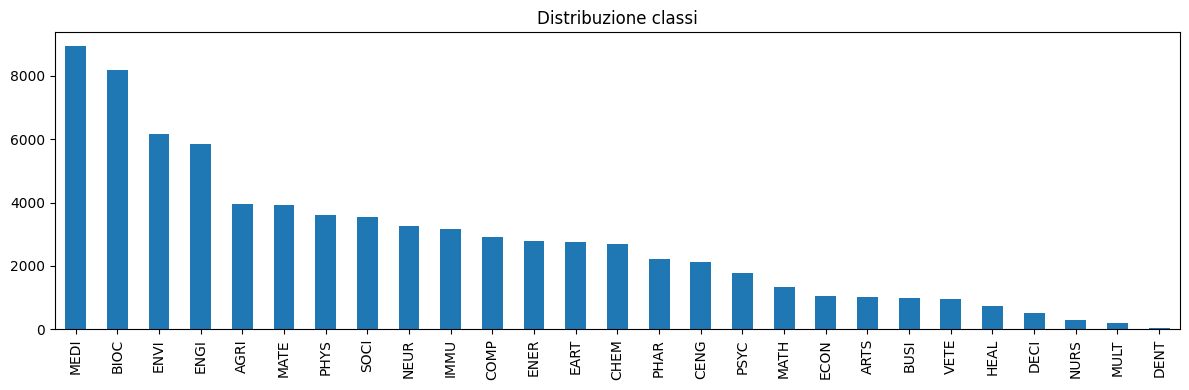

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

label_counts = pd.Series(y.sum(axis=0), index=labels).sort_values(ascending=False)
print(label_counts)

label_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Distribuzione classi")
plt.tight_layout()
plt.show()

In [54]:
label_mapping = {
    "VETE": "MEDI", "HEAL": "MEDI", "DENT": "MEDI", "NURS": "MEDI",
    "ECON": "SOCI", "ARTS": "SOCI", "BUSI": "SOCI", "DECI": "SOCI",
    "MATH": "MULT",
}

def remap_labels(label_list):
    remapped = [label_mapping.get(l, l) for l in label_list]
    return list(set(remapped))

df["labels_remapped"] = df["labels_list"].apply(remap_labels)

mlb_18 = MultiLabelBinarizer()
y_18 = mlb_18.fit_transform(df["labels_remapped"])

labels_18 = mlb_18.classes_
print(f"Classi: {len(labels_18)}")
print(labels_18)

Classi: 18
['AGRI' 'BIOC' 'CENG' 'CHEM' 'COMP' 'EART' 'ENER' 'ENGI' 'ENVI' 'IMMU'
 'MATE' 'MEDI' 'MULT' 'NEUR' 'PHAR' 'PHYS' 'PSYC' 'SOCI']


MEDI    9885
BIOC    8196
ENVI    6166
ENGI    5849
SOCI    5180
AGRI    3942
MATE    3918
PHYS    3604
NEUR    3255
IMMU    3168
COMP    2919
ENER    2796
EART    2743
CHEM    2703
PHAR    2205
CENG    2139
PSYC    1774
MULT    1540
dtype: int64


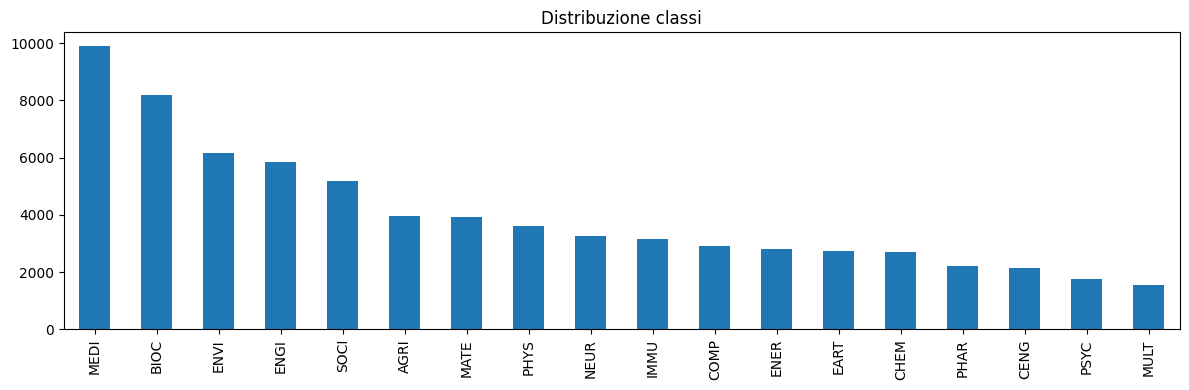

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

labels_18 = pd.Series(y_18.sum(axis=0), index=labels_18).sort_values(ascending=False)
print(labels_18)

labels_18.plot(kind="bar", figsize=(12, 4))
plt.title("Distribuzione classi")
plt.tight_layout()
plt.show()

In [62]:
def build_text(abstract, body, total=500):
    abs_words = str(abstract).split()
    body_words = str(body).split()
    
    abs_take = min(200, len(abs_words))
    body_take = total - abs_take
    
    return " ".join(abs_words[:abs_take]) + " " + " ".join(body_words[:body_take])

df["text"] = df.apply(
    lambda row: build_text(row["preprocessed_abstract"], row["preprocessed_body"]),
    axis=1
)

In [63]:
X = df["text"].astype(str).tolist()
y_18 = np.asarray(y_18, dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_18, test_size=0.3, random_state=42, shuffle=True
)

In [64]:
def tokenize(text):
    return text.split()

counter = Counter()
for text in X_train:
    counter.update(tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
min_freq = 5
for word, freq in counter.items():
    if freq >= min_freq:
        vocab[word] = len(vocab)

vocabulary_size = len(vocab)
print("Vocabulary size:", vocabulary_size)

Vocabulary size: 67522


In [45]:
def find_maxtweet(sequences):
    max_length = len(sequences[0].split())
    for i in range(1, len(sequences)):
        if len(sequences[i].split()) > max_length:
            max_length = len(sequences[i].split())
    return max_length

In [46]:
print(find_maxtweet(df["preprocessed_abstract"]))

618


In [47]:
print(find_maxtweet(df["preprocessed_body"]))

21199


In [50]:
lengths = df["text"].str.split().str.len()
lengths.describe()

count    38711.000000
mean       498.958436
std         10.890650
min        167.000000
25%        500.000000
50%        500.000000
75%        500.000000
max        500.000000
Name: text, dtype: float64

In [65]:
max_len = 500

def encode_text(text):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    ids = ids[:max_len]
    return torch.tensor(ids, dtype=torch.long)

In [66]:
class ArticleDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode_text(self.texts[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts = pad_sequence(texts, batch_first=True, padding_value=vocab["<PAD>"])
    labels = torch.stack(labels)
    return texts, labels

In [67]:
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Calcolo pesi per le 18 classi su y_train
label_freq = y_train.sum(axis=0)
label_weights = 1.0 / np.where(label_freq == 0, 1, label_freq)  # evita divisione per zero
label_weights = label_weights / label_weights.sum()

# Peso per ogni sample = somma dei pesi delle sue label
train_sample_weights = y_train.dot(label_weights)

sampler = WeightedRandomSampler(
    weights=torch.tensor(train_sample_weights, dtype=torch.float),
    num_samples=len(train_sample_weights),
    replacement=True
)

batch_size = 1024

train_dataset = ArticleDataset(X_train, y_train)
val_dataset = ArticleDataset(X_val, y_val)
test_dataset = ArticleDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [68]:
class LSTMMultilabelClassifier(nn.Module):
    def __init__(self, vocabulary_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocabulary_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            dropout=0.2
        )
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMMultilabelClassifier(
    vocabulary_size=vocabulary_size,
    embedding_dim=10,
    hidden_dim=20,
    output_dim=len(labels_18)
).to(device)

# pos_weight per BCEWithLogitsLoss: penalizza classi rare
pos_weight = torch.tensor(
    (len(y_train) - y_train.sum(axis=0)) / np.where(y_train.sum(axis=0) == 0, 1, y_train.sum(axis=0)),
    dtype=torch.float
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(model)

LSTMMultilabelClassifier(
  (embedding): Embedding(67522, 10, padding_idx=0)
  (lstm): LSTM(10, 20, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=20, out_features=18, bias=True)
)


c:\Users\Bombino\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [70]:
from tqdm import tqdm
from sklearn.metrics import f1_score

epochs = 30
train_losses, val_losses, train_f1s, val_f1s = [], [], [], []

print("Train...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_preds, all_targets = [], []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for texts, targets in train_bar:
        texts = texts.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets.cpu().numpy())

        train_bar.set_postfix(loss=f"{total_loss/len(train_loader):.4f}")

    avg_loss = total_loss / len(train_loader)
    avg_f1 = f1_score(np.vstack(all_targets), np.vstack(all_preds), average="micro", zero_division=0)
    train_losses.append(avg_loss)
    train_f1s.append(avg_f1)

    # Validation
    model.eval()
    val_loss = 0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for texts, targets in val_loader:
            texts = texts.to(device)
            targets = targets.to(device)
            outputs = model(texts)
            val_loss += criterion(outputs, targets).item()
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            val_preds.append(preds)
            val_targets.append(targets.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_f1 = f1_score(np.vstack(val_targets), np.vstack(val_preds), average="micro", zero_division=0)
    val_losses.append(avg_val_loss)
    val_f1s.append(avg_val_f1)

    print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - f1: {avg_f1:.4f} - val_loss: {avg_val_loss:.4f} - val_f1: {avg_val_f1:.4f}")

Train...


Epoch 1/30 - loss: 1.4961 - f1: 0.2171 - val_loss: 1.2456 - val_f1: 0.1822


Epoch 2/30 - loss: 1.4697 - f1: 0.2183 - val_loss: 1.2548 - val_f1: 0.1575


Epoch 3/30 - loss: 1.4403 - f1: 0.2147 - val_loss: 1.2928 - val_f1: 0.1538


Epoch 4/30 - loss: 1.4324 - f1: 0.2174 - val_loss: 1.2860 - val_f1: 0.1547


...

Epoch 26/30 - loss: 1.2414 - f1: 0.3126 - val_loss: 1.1556 - val_f1: 0.2450


Epoch 27/30 - loss: 1.2372 - f1: 0.3168 - val_loss: 1.1506 - val_f1: 0.2485


Epoch 28/30 - loss: 1.2307 - f1: 0.3197 - val_loss: 1.1515 - val_f1: 0.2509


Epoch 29/30 - loss: 1.2234 - f1: 0.3198 - val_loss: 1.1484 - val_f1: 0.2519


Epoch 30/30 - loss: 1.2231 - f1: 0.3217 - val_loss: 1.1458 - val_f1: 0.2524


Funzioni utili

In [27]:
# Evaluation model
def model_evaluation(real_v, pred_v):
    print(f"Accuracy score: {accuracy_score(real_v, pred_v)}")
    print("Classification report:")
    print(classification_report(real_v, pred_v))
    cm = confusion_matrix(real_v, pred_v)
    print (f"Confusion matrix \n {cm}")

In [28]:
# Plot Training & validation ACCURACY then training and validation LOSS -> res = RNN fitted
def plot_Loss(res):
    train_acc = res.history['accuracy']
    val_acc = res.history['val_accuracy']
    train_loss = res.history['loss']
    val_loss = res.history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, train_acc, 'g', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, train_loss, 'g', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()

In [29]:
# Find longest tweet in sequences
def find_maxtweet(sequences):
    max_length = len(sequences[0])
    for i in range(1, len(sequences)):
        if len(sequences[i]) > max_length:
            max_length = len(sequences[i])
    return max_length

# Embedding Layer

E' il primo livello  della rete neurale che incorpora i dati di input in vettori. Deve specifiare 3 argomenti:

- input_dim -> dimensione vocabolario dei dati di testo (conto parole uniche nei tweets)
- output_dim -> questa è la dimensione dello spazio vettoriale in cui verranno incorporate le parole. Definisce la dimensione dei vettori di output per ogni parola. (Sono stati provati diversi valori e si è deciso di settarlo a 10D)
- input_length ->  questa è la lunghezza delle sequenze di input(viene preso la lunghezza del tweet più lungo)

# LSTM Layer

E' il secondo livello della NN; definisce la ricorrenza della Rete Neurale ed ha memoria sia a breve che a lungo termine. Può processare singoli dati o sequenze.
Gli argomenti principali sono:

- units: interi positivi, dimensionalità dello spazio di output
- dropout: Float between 0 and 1. Frazione delle units da droppare per la trasformazione dell'input. default=0
- recurrent_dropout: Float between 0 and 1. Frazione delle units da droppare per la trasformazione dell'input dello stato ricorrente. default=0
- activation: funzione di attivazione, di default è la tangente iperbolica


# Dense Layer

E' l'ultimo livello della rete neurale, ogni neurone riceve input da tutti i neuroni del layer precedente, per questo definito "denso".

Implementa l'operazione: output = activation(dot(input, kernel) + bias) dove activation=funzione di attivazione, kernel=matrice dei pesi del layer, bias=vettore bias creato dal layer(applicabile solo se us_bias è True)

Gli argomenti principali sono:
- units:viene utilizzata una singola unità
- activation

In [30]:
# Convert training data into tensors to feed into neural net
t = Tokenizer()
t.fit_on_texts(X) # index dictionary so every word gets a unique integer value. 

# Find number of unique words in our tweets
vocabulary_size= len(t.word_index) +1

# transform each tweet in a sequence of integers
sequences = t.texts_to_sequences(X)

#find longest tweet
max_tweet=find_maxtweet(sequences)

#Le sequenze hanno lunghezze diverse e Keras preferisce che gli input siano vettorizzati e che tutti gli input abbiano la stessa lunghezza
# quindi aggiungiamo 0 alla fine di ogni sequenza affinchè siano tutte di lunghezza=max_tweet
padded_X= pad_sequences(sequences, padding='post', maxlen=max_tweet)


# Esperimento senza pre-trained embedded layer

In [31]:
#holdout
X_train, X_test, y_train, y_test = train_test_split(padded_X, y, test_size = 0.3)

#First layer -> embedded without pre-trained weight matrix
embedding_layer = Embedding(input_dim=vocabulary_size,output_dim=10,input_length = max_tweet)

#Second layer -> LSTM
LSTM_layer=LSTM(20, dropout=0.2, recurrent_dropout=0.2)

#Last layer -> Dense
dense_layer=Dense(1, activation='sigmoid')


#Build RNN
print('Build model...')
model = Sequential()
model.add(embedding_layer)
model.add(LSTM_layer)
model.add(dense_layer)
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Build model...
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 31, 10)            402730    
                                                                 
 lstm_2 (LSTM)               (None, 20)                2480      
                                                                 
 dense_2 (Dense)             (None, 1)                 21        
                                                                 
Total params: 405,231
Trainable params: 405,231
Non-trainable params: 0
_________________________________________________________________


In [32]:
batch_size=1024 # training examples used for each epoch 
epochs=30 
print('Train...')
res=model.fit(X_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          validation_split=0.1)

Train...
Epoch 1/30
33/33 [==============================] - 3s 39ms/step - loss: 0.6875 - accuracy: 0.5587 - val_loss: 0.6867 - val_accuracy: 0.5535
Epoch 2/30
33/33 [==============================] - 1s 31ms/step - loss: 0.6614 - accuracy: 0.5797 - val_loss: 0.4926 - val_accuracy: 0.8262
Epoch 3/30
33/33 [==============================] - 1s 30ms/step - loss: 0.3719 - accuracy: 0.8785 - val_loss: 0.3146 - val_accuracy: 0.8875
Epoch 4/30
33/33 [==============================] - 1s 29ms/step - loss: 0.2305 - accuracy: 0.9282 - val_loss: 0.2419 - val_accuracy: 0.9151
Epoch 5/30
33/33 [==============================] - 1s 30ms/step - loss: 0.1572 - accuracy: 0.9532 - val_loss: 0.2109 - val_accuracy: 0.9266
Epoch 6/30
33/33 [==============================] - 1s 29ms/step - loss: 0.1186 - accuracy: 0.9665 - val_loss: 0.2203 - val_accuracy: 0.9244
Epoch 7/30
33/33 [==============================] - 1s 29ms/step - loss: 0.0935 - accuracy: 0.9741 - val_loss: 0.2269 - val_accuracy: 0.9277
Epoc

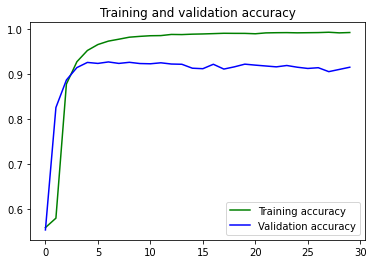

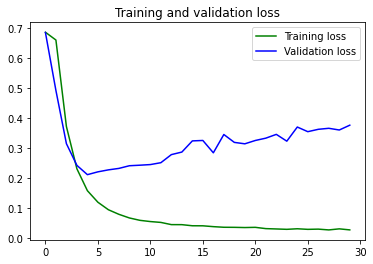

In [33]:
plot_Loss(res)

In [34]:
loss, accuracy = model.evaluate(X_train, y_train, verbose=False)
print("Training Accuracy: {:.4f}".format(accuracy))
loss, accuracy = model.evaluate(X_test, y_test, verbose=False)
print("Testing Accuracy:  {:.4f}".format(accuracy))

Training Accuracy: 0.9881
Testing Accuracy:  0.9190


In [35]:
predictions=model.predict(X_test).round().flatten() # converts predictions in integers then in 1D
predictions

490/490 [==============================] - 1s 1ms/step


array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [36]:
predicted_labels = [int(a) for a in predictions]
predicted_labels

[0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,


In [37]:
model_evaluation(y_test,predicted_labels)

Accuracy score: 0.9189931642496646
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      8726
           1       0.91      0.90      0.91      6927

    accuracy                           0.92     15653
   macro avg       0.92      0.92      0.92     15653
weighted avg       0.92      0.92      0.92     15653

Confusion matrix 
 [[8137  589]
 [ 679 6248]]


# Esperimento con pre-trained embedded layer 

Viene utilizzato un file di parole GloVe(Global vectors for word representation) come un dizionario di array di parole da incorporare. GloVe è un algoritmo di apprendimento non supervisionato per ottenere rappresentazioni vettoriali di testi. Le parole sono rappresentate da vettori pre-allenati. L'addestramento è stato eseguito su statistiche globali aggregate di co-occorrenza parola-parola da diversi tweet.(Il file contiene infatti circa 1M di word vectors). Nel seguito vengono estratti i vettori delle parole che compaiono nei tweet del dataset e viene utilizzata tale rappresentazione vettoriale coma matrice dei pesi per il primo livello di Embedding della rete neurale.

In [2]:
#dizionario pre-addestrato
embeddings_index = dict()
f = open("glove.twitter.27B.25d.txt", encoding='utf-8')

for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()
print('Loaded %s word vectors.' % len(embeddings_index))

Loaded 1193514 word vectors.


Viene creata una matrice di embedding andando ad aggiungere il vettore del peso di incorporamento di Glove, solo per le parole dei tweets presenti in X="preprocessed_text"

In [39]:
embedding_matrix = np.zeros((vocabulary_size, 25))

# fill in matrix
for word, i in t.word_index.items():  # dictionary tweets
    embedding_vector = embeddings_index.get(word) # gets embedded vector of word from GloVe
    if embedding_vector is not None:
        # add to matrix
        embedding_matrix[i] = embedding_vector # each row of matrix

Adesso nel livello di embedding abbiamo la matrice dei pesi delle parole che erano anche nel file Glove. Risulta necessario impostare output_dim=25 perchè è la dimensione con cui è stata definita la matrice dei pesi Glove.

In [40]:
#First layer -> embedded with pre-trained weight matrix
embedding_layer = Embedding(input_dim=vocabulary_size, output_dim=25, weights=[embedding_matrix], input_length = max_tweet, trainable=False)

#Second layer -> LSTM
LSTM_layer=LSTM(20,dropout = 0.2, recurrent_dropout = 0.2)

#Last layer -> Dense
dense_layer=Dense(1, activation='sigmoid')

In [41]:
model2=Sequential()
model2.add(embedding_layer)
model2.add(LSTM_layer)
model2.add(dense_layer)
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 31, 25)            1006825   
                                                                 
 lstm_3 (LSTM)               (None, 20)                3680      
                                                                 
 dense_3 (Dense)             (None, 1)                 21        
                                                                 
Total params: 1,010,526
Trainable params: 3,701
Non-trainable params: 1,006,825
_________________________________________________________________


In [42]:
res2 = model2.fit(X_train, y_train,
                    validation_split = 0.1,
                    epochs=30, batch_size=1024)

Epoch 1/30
33/33 [==============================] - 4s 62ms/step - loss: 0.6756 - accuracy: 0.5948 - val_loss: 0.6055 - val_accuracy: 0.7832
Epoch 2/30
33/33 [==============================] - 2s 55ms/step - loss: 0.4473 - accuracy: 0.8439 - val_loss: 0.3555 - val_accuracy: 0.8733
Epoch 3/30
33/33 [==============================] - 2s 55ms/step - loss: 0.3456 - accuracy: 0.8706 - val_loss: 0.3164 - val_accuracy: 0.8817
Epoch 4/30
33/33 [==============================] - 2s 56ms/step - loss: 0.3129 - accuracy: 0.8779 - val_loss: 0.2922 - val_accuracy: 0.8864
Epoch 5/30
33/33 [==============================] - 2s 56ms/step - loss: 0.2971 - accuracy: 0.8824 - val_loss: 0.2801 - val_accuracy: 0.8880
Epoch 6/30
33/33 [==============================] - 2s 56ms/step - loss: 0.2861 - accuracy: 0.8875 - val_loss: 0.2788 - val_accuracy: 0.8872
Epoch 7/30
33/33 [==============================] - 2s 57ms/step - loss: 0.2795 - accuracy: 0.8911 - val_loss: 0.2644 - val_accuracy: 0.8910
Epoch 8/30
33

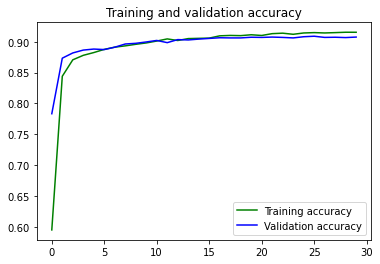

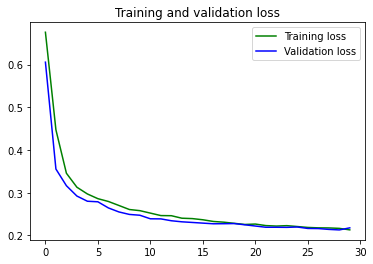

In [43]:
plot_Loss(res2)

In [44]:
# Find train and test accuracy
loss, accuracy = model2.evaluate(X_train, y_train, verbose=False)
print("Training Accuracy: {:.4f}".format(accuracy))
loss, accuracy = model2.evaluate(X_test, y_test, verbose=False)
print("Testing Accuracy:  {:.4f}".format(accuracy))

Training Accuracy: 0.9217
Testing Accuracy:  0.9163


In [ ]:
predictions2=model2.predict(X_test).round().flatten()

In [ ]:
predicted_labels2 = [int(a) for a in predictions2]

In [45]:
model_evaluation(y_test, predicted_labels2)

490/490 [==============================] - 1s 1ms/step
Accuracy score: 0.9163099725292276
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      8726
           1       0.92      0.89      0.90      6927

    accuracy                           0.92     15653
   macro avg       0.92      0.91      0.91     15653
weighted avg       0.92      0.92      0.92     15653

Confusion matrix 
 [[8186  540]
 [ 770 6157]]
